In [1]:
# to run this file you need to have the following files in the same directory:
# - test_data/bikes.csv
# install igann with:
# pip install git+https://github.com/MathiasKraus/igann.git@GAM_wrapper
# install i2dgraph with:
# pip install i2dgraph
# install dash with:
# pip install dash

In [2]:
pip install git+https://github.com/MathiasKraus/igann.git@GAM_wrapper

Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/MathiasKraus/igann.git (to revision GAM_wrapper) to /tmp/pip-req-build-05wh3ybx
  Running command git clone --filter=blob:none --quiet https://github.com/MathiasKraus/igann.git /tmp/pip-req-build-05wh3ybx
  Running command git checkout -b GAM_wrapper --track origin/GAM_wrapper
  Switched to a new branch 'GAM_wrapper'
  branch 'GAM_wrapper' set up to track 'origin/GAM_wrapper'.
  Resolved https://github.com/MathiasKraus/igann.git to commit 2cb9d441ecd72e200aa417f69c80a153b0c21170
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install i2dgraph

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install dash

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install dash-bootstrap-components

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
# import libs
import igann
import i2dgraph


import json

# import standard libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from pprint import pprint as pp  # pretty print
import os

# function to load example dataset
from sklearn.datasets import fetch_california_housing

# Load the dataset
df = pd.read_csv("./content/sample_data/bike.csv")

FileNotFoundError: [Errno 2] No such file or directory: './content/sample_data/bike.csv'

In [ ]:
# remap numeric features
def scale_values(values, new_min, new_max):
    if isinstance(values, (pd.Series, pd.DataFrame)):
        old_min, old_max = values.min(), values.max()
        return (values - old_min) / (old_max - old_min) * (new_max - new_min) + new_min

    arr = np.array(values)
    old_min, old_max = arr.min(), arr.max()
    return (arr - old_min) / (old_max - old_min) * (new_max - new_min) + new_min


df["Time of Day"] = df["hr"]
df["Windspeed"] = scale_values(df["windspeed"], 0, 67)
df["Temperature"] = scale_values(df["temp"], -8, 39)
df["Perceived Temperature"] = scale_values(df["atemp"], -16, 50)
df["Humidity"] = scale_values(df["hum"], 0, 100)


# remap cat features for correct categorys
# Rename season values
df["Season"] = df["season"].replace({1: "Winter", 2: "Spring", 3: "Summer", 4: "Fall"})
df["Weathersituation"] = df["weathersit"].replace(
    # {1: "Clear", 2: "Mist", 3: "Light Rain", 4: "Heavy Rain"}
    {
        1: "Clear",
        2: "Cloudy",
        3: "Light Rain",
        4: "Heavy Rain",
    }
)


# Create Day Type variable based on Working Day, Weekend, Holiday
df["Type of Day"] = np.where(
    (df["workingday"] == 1) & (df["holiday"] == 0),
    "Working Day",
    np.where((df["workingday"] == 0) & (df["holiday"] == 0), "Weekend", "Holiday"),
)


df.dropna(subset=["cnt"], inplace=True)

print(df.info())

# set correct nan
df.replace("-", np.nan, inplace=True)

# drop examples with nans
df.dropna(inplace=True)

# set X and y
y = pd.DataFrame(df["cnt"])


# drop old and not needed columns
feature_to_drop = [
    # we also drop the columns with the old names
    "dteday",
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weathersit",
    "temp",
    "atemp",
    "hum",
    "windspeed",
    "cnt",
    "instant",
    "workingday",
    "casual",
    "registered",
    "weekday",
    # also remove some renamed
    # "Temperature",
    # "Weathersituation",
    "Perceived Temperature",
    "Season",
    # "Time of Day",
    # "Type of Day",
    # "Humidity"
    # "Windspeed"
]

X = df.drop(columns=feature_to_drop, inplace=False)
print(X.shape)


print(X.describe())
print(X.info())

In [ ]:
# very normal preprocessing
# from feature_engine.outliers import Winsorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


# define feature types for preprocessing (also make sure to use the correct type in the datagframe)
# define cat

# this dataset has not cats
cat_features = [
    "Weathersituation",
    # "Perceived Temperature",
    # "Season",
    "Time of Day",
    "Type of Day",
    # "Humidity"
    # "Windspeed"
]

# define numeric features
num_features = [feature for feature in X.columns if feature not in cat_features]

# do some imputations

# create transformer for num features
num_Transformer = Pipeline(
    [
        (
            "num_imputer",
            SimpleImputer(strategy="mean"),
        ),
    ]
)

# create transformer for cat features
cat_Transformer = Pipeline(
    [
        # no one-hot-encoding is use here (igann does this by it self)
        (
            "cat_imputer",
            SimpleImputer(strategy="most_frequent"),
        )
    ]
)

# wrap it in CloumnTransformer
column_Transformer = ColumnTransformer(
    transformers=[
        ("num", num_Transformer, num_features),
        ("cat", cat_Transformer, cat_features),
    ],
    verbose_feature_names_out=False,
).set_output(transform="pandas")

# transform X
X = column_Transformer.fit_transform(X)
X = X.astype(
    {
        # "yr": "object",
        # "mnth": "object",
        "Time of Day": "object",
        "Type of Day": "object",
        "Weathersituation": "object",
    }
)


print(X.info())
X.describe()

In [ ]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# print(X_train_reduced.shape)

In [ ]:
# train 2 models

# first normal igann
from igann import IGANN

igann = IGANN(
    task="regression",
    n_estimators=100,
    verbose=0,
    scale_y=True,
)  # 1,

igann.fit(X_train, y_train)

# second igann interactive
from igann import IGANN_interactive

igann_i = IGANN_interactive(
    task="regression",
    n_estimators=100,
    regressor_limit=100,  # set this to n_estimator otherwise wired things can happen
    verbose=0,  # 1,
    GAM_detail=100,  # number of points used to save and represent the shapefunction
    scale_y=True,  # this is for regression essential we use internal scaling to have understandable shapefunctions
)
igann_i.fit(X_train, y_train)

# just to compare the shape functions
igann.plot_single(show_n=8)

# igann_i.plot_single(show_n=8)

# this is to start the interaction mode
igann_i.interact()

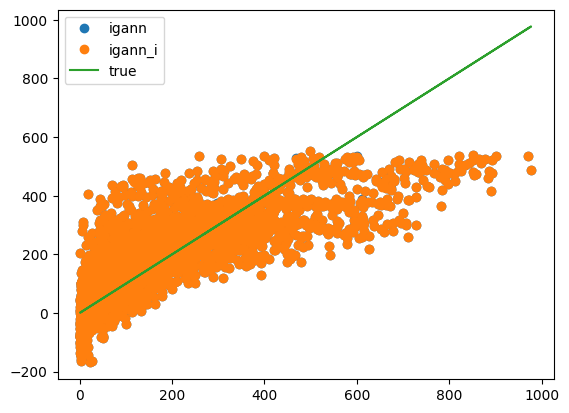

igann: rsme, mae = (111.27853058107118, 81.1933563027079)
igann_interactive: rsme, mae = (111.27385939094458, 81.17855890482797)


In [11]:
from sklearn.metrics import (
    roc_auc_score,
    root_mean_squared_error,
    mean_squared_error,
    mean_absolute_error,
)


def test_model(model, X, y):
    y_pred = model.predict(X)
    rsme = root_mean_squared_error(y, y_pred)
    mae = mean_absolute_error(y, y_pred)

    return rsme, mae


def test_model_cliped(model, X, y):
    y_pred = model.predict(X)
    y_pred = np.clip(y_pred, 0, 1000)
    rsme = root_mean_squared_error(y, y_pred)
    mae = mean_absolute_error(y, y_pred)

    return rsme, mae


y_pred_igann = igann.predict(X_test)
y_pred_igann_i = igann_i.predict(X_test)




plt.plot(y_test, y_pred_igann, "o", label="igann")
plt.plot(y_test, y_pred_igann_i, "o", label="igann_i")
plt.plot(y_test, y_test, "-", label="true")

plt.legend()
plt.show()

print(f"igann: rsme, mae = {test_model(igann, X_test, y_test)}")
print(f"igann_interactive: rsme, mae = {test_model(igann_i, X_test, y_test)}")

